# MatRisk AI — Bonus Task: Cost-Aware Inverse Material Design
**EXCAVATE | COMPOSIT 31st Edition | IIT Kharagpur**

---

## Objective
Explore **inverse material design** — instead of predicting properties of existing materials,
we propose **new material compositions** (alloys/compounds) that:
1. Achieve strong predicted MQI (high performance)
2. Remain economically feasible (low cost)
3. Identify materials with the best **performance-cost trade-off**

We use:
- **DS1** — to train a property prediction model
- **DS4** — MQI weights
- **DS5** — element prices to estimate material cost
- **Candidate elements**: Fe, Ni, Cu, Li, Co, Nd (as specified in problem statement)

---

## Step 1 — Load All Required Datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from itertools import combinations_with_replacement
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries loaded successfully')

Libraries loaded successfully


In [2]:
# Load datasets
ds1 = pd.read_csv('DS1_material_properties_5500.csv')
ds4 = pd.read_csv('DS4_ mqi_weights.csv')
ds5 = pd.read_csv('DS5_element_prices_monthly.csv')

print('DS1 shape:', ds1.shape)
print('DS4 shape:', ds4.shape)
print('DS5 shape:', ds5.shape)
print()
print('DS4 Weights:')
print(ds4)

DS1 shape: (5500, 18)
DS4 shape: (6, 2)
DS5 shape: (5280, 5)

DS4 Weights:
            Property  Weights
0   Bulk Modulus (K)     0.20
1  Shear Modulus (G)     0.20
2   Formation Energy     0.20
3            Density     0.10
4      Melting Point     0.15
5           Band Gap     0.15


---
## Step 2 — Recalculate MQI for DS1

Same formula as Task 1 — we need MQI as target for training the property prediction model.

In [3]:
def normalise(series):
    """Min-Max normalise to 0-100"""
    return (series - series.min()) / (series.max() - series.min()) * 100

df = ds1.copy()

df['norm_bulk']      = normalise(df['bulk_modulus_GPa'])
df['norm_shear']     = normalise(df['shear_modulus_GPa'])
df['norm_density']   = normalise(df['density_g_cm3'])
df['norm_melting']   = normalise(df['melting_point_K'])
df['norm_bandgap']   = normalise(df['band_gap_eV'])
df['norm_formation'] = normalise(-df['formation_energy_per_atom_eV'])

df['MQI'] = (0.20 * df['norm_bulk'] +
             0.20 * df['norm_shear'] +
             0.20 * df['norm_formation'] +
             0.10 * df['norm_density'] +
             0.15 * df['norm_melting'] +
             0.15 * df['norm_bandgap'])

print('MQI calculated.')
print(f'MQI range: {df["MQI"].min():.2f} to {df["MQI"].max():.2f}')
print(f'Mean MQI: {df["MQI"].mean():.2f}')

MQI calculated.
MQI range: 4.74 to 66.03
Mean MQI: 27.43


---
## Step 3 — Get Latest Element Prices from DS5

We use the most recent price for each element to estimate the cost of new candidate materials.

In [4]:
ds5['date'] = pd.to_datetime(ds5['date'])

# Get latest price per element
latest_prices = ds5.sort_values('date').groupby('element').last()[['price_usd_per_kg']].reset_index()
price_dict = dict(zip(latest_prices['element'], latest_prices['price_usd_per_kg']))

print('Latest prices for candidate elements (USD/kg):')
candidates = ['Fe', 'Ni', 'Cu', 'Li', 'Co', 'Nd']
for elem in candidates:
    print(f'  {elem}: ${price_dict.get(elem, "N/A"):.2f}/kg')

Latest prices for candidate elements (USD/kg):
  Fe: $0.09/kg
  Ni: $17.92/kg
  Cu: $9.15/kg
  Li: $27.33/kg
  Co: $53.05/kg
  Nd: $79.83/kg


---
## Step 4 — Extract Element Composition from DS1

To build a cost model, we need to know which elements are in each material.
We extract element presence from the formula column using regex.
This creates binary features: does this material contain Fe? Ni? Cu? etc.

In [5]:
import re

def extract_elements(formula):
    """Extract all element symbols from a chemical formula like Fe4Ba2ScC3"""
    # Match uppercase letter followed by optional lowercase letter
    return re.findall(r'[A-Z][a-z]?', formula)

# All unique elements in DS5
all_elements = list(price_dict.keys())

# Create binary presence columns for each element in DS5
for elem in all_elements:
    df[f'has_{elem}'] = df['formula'].apply(lambda x: 1 if elem in extract_elements(x) else 0)

print(f'Added {len(all_elements)} element presence features')
print('Sample:')
elem_cols = [f'has_{e}' for e in ['Fe', 'Ni', 'Cu', 'Li', 'Co']]
print(df[['formula'] + elem_cols].head(8))

Added 40 element presence features
Sample:
      formula  has_Fe  has_Ni  has_Cu  has_Li  has_Co
0    Ta3Au3H2       0       0       0       0       0
1    Al3Rh4W3       0       0       0       0       0
2      Pd3Te3       0       0       0       0       0
3      Ne4Cd4       0       0       0       0       0
4       Al4Rh       0       0       0       0       0
5    SbCu2Re2       0       0       1       0       0
6  Fe4Ba2ScC3       1       0       0       0       0
7       Y3Ge2       0       0       0       0       0


In [6]:
# Estimate material cost from DS1: average price of constituent elements
def estimate_cost(formula, price_dict):
    """Estimate cost as average price of elements present in formula"""
    elements = extract_elements(formula)
    prices = [price_dict[e] for e in elements if e in price_dict]
    return np.mean(prices) if prices else np.nan

df['estimated_cost'] = df['formula'].apply(lambda x: estimate_cost(x, price_dict))

print('Cost estimation complete.')
print(f'Materials with cost estimate: {df["estimated_cost"].notna().sum()}')
print()
print('Cost statistics (USD/kg):')
print(df['estimated_cost'].describe())

Cost estimation complete.
Materials with cost estimate: 4760

Cost statistics (USD/kg):
count     4760.000000
mean      2405.975180
std       8129.765276
min          0.090000
25%          8.530000
50%         30.040000
75%        450.990000
max      57479.250000
Name: estimated_cost, dtype: float64


---
## Step 5 — Train MQI Prediction Model

We train a model to predict MQI from material features.
This model will later be used to estimate MQI for **new candidate materials** we propose.

In [7]:
# Encode categorical features
le_crystal = LabelEncoder()
le_category = LabelEncoder()
df['crystal_system_enc'] = le_crystal.fit_transform(df['crystal_system'])
df['category_enc']       = le_category.fit_transform(df['category'])

# Feature columns for MQI prediction
base_features = [
    'n_elements', 'crystal_system_enc', 'category_enc', 'spacegroup_number',
    'formation_energy_per_atom_eV', 'energy_above_hull_eV', 'band_gap_eV',
    'is_metal', 'bulk_modulus_GPa', 'shear_modulus_GPa', 'poisson_ratio',
    'density_g_cm3', 'nsites', 'volume_A3', 'melting_point_K', 'is_stable'
]

X = df[base_features]
y = df['MQI']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Gradient Boosting (best from Task 1)
mqi_model = GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42)
mqi_model.fit(X_train, y_train)
y_pred = mqi_model.predict(X_test)

print(f'MQI Prediction Model R²:  {r2_score(y_test, y_pred):.4f}')
print(f'MQI Prediction Model MAE: {mean_absolute_error(y_test, y_pred):.4f}')
print()
print('Model trained — ready to predict MQI for new candidate materials.')

MQI Prediction Model R²:  0.9910
MQI Prediction Model MAE: 0.6526

Model trained — ready to predict MQI for new candidate materials.


---
## Step 6 — Generate Candidate Materials

We propose new binary and ternary alloy/compound candidates using:
**Fe, Ni, Cu, Li, Co, Nd** (as specified in the problem statement)

Strategy: use the property statistics of existing materials containing these elements
to estimate plausible property ranges for new compositions.

In [8]:
# Get average properties of materials containing each candidate element
candidate_elements = ['Fe', 'Ni', 'Cu', 'Li', 'Co']
# Note: Nd not in DS1 formulas, so we use the 5 that are present

elem_profiles = {}
for elem in candidate_elements:
    subset = df[df[f'has_{elem}'] == 1]
    if len(subset) > 0:
        elem_profiles[elem] = {
            'formation_energy_per_atom_eV': subset['formation_energy_per_atom_eV'].mean(),
            'energy_above_hull_eV':         subset['energy_above_hull_eV'].mean(),
            'band_gap_eV':                  subset['band_gap_eV'].mean(),
            'is_metal':                     subset['is_metal'].mean().round(),
            'bulk_modulus_GPa':             subset['bulk_modulus_GPa'].mean(),
            'shear_modulus_GPa':            subset['shear_modulus_GPa'].mean(),
            'poisson_ratio':                subset['poisson_ratio'].mean(),
            'density_g_cm3':                subset['density_g_cm3'].mean(),
            'nsites':                       subset['nsites'].mean(),
            'volume_A3':                    subset['volume_A3'].mean(),
            'melting_point_K':              subset['melting_point_K'].mean(),
            'is_stable':                    subset['is_stable'].mean().round(),
            'count':                        len(subset)
        }

print('Element profiles (avg properties of DS1 materials containing each element):')
for elem, profile in elem_profiles.items():
    print(f'  {elem}: {profile["count"]} materials, avg bulk={profile["bulk_modulus_GPa"]:.1f} GPa, avg melting={profile["melting_point_K"]:.0f} K')

Element profiles (avg properties of DS1 materials containing each element):
  Fe: 239 materials, avg bulk=140.9 GPa, avg melting=1573 K
  Ni: 199 materials, avg bulk=138.3 GPa, avg melting=1576 K
  Cu: 239 materials, avg bulk=139.6 GPa, avg melting=1555 K
  Li: 210 materials, avg bulk=134.5 GPa, avg melting=1567 K
  Co: 228 materials, avg bulk=144.6 GPa, avg melting=1622 K


In [9]:
# Generate binary and ternary candidate compositions
# Strategy: blend element profiles with different weight ratios

candidates = []

# Binary combinations
for e1, e2 in combinations_with_replacement(candidate_elements, 2):
    if e1 == e2:
        continue
    for ratio in [0.25, 0.5, 0.75]:  # different mixing ratios
        p1 = elem_profiles[e1]
        p2 = elem_profiles[e2]
        blended = {}
        for key in base_features:
            if key in ['crystal_system_enc', 'category_enc', 'spacegroup_number', 'n_elements']:
                continue
            blended[key] = ratio * p1[key] + (1 - ratio) * p2[key]
        blended['n_elements'] = 2
        blended['crystal_system_enc'] = 0  # cubic (most common)
        blended['category_enc'] = 4        # Intermetallic
        blended['spacegroup_number'] = 225  # Fm-3m (common FCC)
        blended['name'] = f'{e1}{int(ratio*4)}{e2}{int((1-ratio)*4)}'
        blended['elements'] = [e1, e2]
        candidates.append(blended)

# Ternary combinations
for e1, e2, e3 in combinations_with_replacement(candidate_elements, 3):
    if len(set([e1, e2, e3])) < 3:
        continue
    p1, p2, p3 = elem_profiles[e1], elem_profiles[e2], elem_profiles[e3]
    blended = {}
    for key in base_features:
        if key in ['crystal_system_enc', 'category_enc', 'spacegroup_number', 'n_elements']:
            continue
        blended[key] = (p1[key] + p2[key] + p3[key]) / 3
    blended['n_elements'] = 3
    blended['crystal_system_enc'] = 0
    blended['category_enc'] = 4
    blended['spacegroup_number'] = 225
    blended['name'] = f'{e1}{e2}{e3}'
    blended['elements'] = [e1, e2, e3]
    candidates.append(blended)

print(f'Generated {len(candidates)} candidate materials')
print(f'  Binary compositions:  {sum(1 for c in candidates if c["n_elements"]==2)}')
print(f'  Ternary compositions: {sum(1 for c in candidates if c["n_elements"]==3)}')

Generated 40 candidate materials
  Binary compositions:  30
  Ternary compositions: 10


---
## Step 7 — Predict MQI and Estimate Cost for Each Candidate

In [10]:
# Build feature matrix for all candidates
cand_df = pd.DataFrame(candidates)  # ← no columns= argument, let it take all keys

# Predict MQI using trained model
X_cand = cand_df[base_features]  # ← select only base_features for prediction
cand_df['predicted_MQI'] = mqi_model.predict(X_cand)

# Estimate cost: average price of constituent elements
def estimate_candidate_cost(elements):
    prices = [price_dict.get(e, np.nan) for e in elements]
    prices = [p for p in prices if not np.isnan(p)]
    return np.mean(prices) if prices else np.nan

cand_df['estimated_cost_usd_kg'] = cand_df['elements'].apply(estimate_candidate_cost)

# Performance-cost ratio: higher MQI per dollar = better trade-off
cand_df['performance_cost_ratio'] = cand_df['predicted_MQI'] / cand_df['estimated_cost_usd_kg']

print('Predictions complete.')
print(cand_df[['name', 'predicted_MQI', 'estimated_cost_usd_kg', 'performance_cost_ratio']].head(10))

Predictions complete.
     name  predicted_MQI  estimated_cost_usd_kg  performance_cost_ratio
0  Fe1Ni3      27.090694                  9.005                3.008406
1  Fe2Ni2      27.090694                  9.005                3.008406
2  Fe3Ni1      27.090694                  9.005                3.008406
3  Fe1Cu3      25.486031                  4.620                5.516457
4  Fe2Cu2      26.725917                  4.620                5.784831
5  Fe3Cu1      26.797591                  4.620                5.800344
6  Fe1Li3      26.288388                 13.710                1.917461
7  Fe2Li2      27.090694                 13.710                1.975981
8  Fe3Li1      27.090694                 13.710                1.975981
9  Fe1Co3      27.737970                 26.570                1.043958


---
## Step 8 — Identify Best Performance-Cost Trade-offs

We rank candidates by:
1. Highest MQI (raw performance)
2. Lowest cost
3. Best performance/cost ratio (the real winner)

In [11]:
results = cand_df[['name', 'n_elements', 'predicted_MQI',
                    'estimated_cost_usd_kg', 'performance_cost_ratio']].dropna()

print('=== TOP 10 BY MQI (Best Performance) ===')
print(results.sort_values('predicted_MQI', ascending=False).head(10).to_string(index=False))
print()
print('=== TOP 10 BY PERFORMANCE-COST RATIO (Best Trade-off) ===')
print(results.sort_values('performance_cost_ratio', ascending=False).head(10).to_string(index=False))
print()
print('=== TOP 10 LOWEST COST (Most Economical) ===')
print(results.sort_values('estimated_cost_usd_kg').head(10).to_string(index=False))

=== TOP 10 BY MQI (Best Performance) ===
  name  n_elements  predicted_MQI  estimated_cost_usd_kg  performance_cost_ratio
Cu1Co3           2      27.737970              31.100000                0.891896
Fe1Co3           2      27.737970              26.570000                1.043958
Ni1Co3           2      27.309426              35.485000                0.769605
Li1Co3           2      27.309426              40.190000                0.679508
Fe2Co2           2      27.269293              26.570000                1.026319
Fe3Co1           2      27.269293              26.570000                1.026319
Ni3Co1           2      27.269293              35.485000                0.768474
Ni2Co2           2      27.269293              35.485000                0.768474
FeNiCo           3      27.269293              23.686667                1.151251
FeLiCo           3      27.269293              26.823333                1.016626

=== TOP 10 BY PERFORMANCE-COST RATIO (Best Trade-off) ===
  name  n

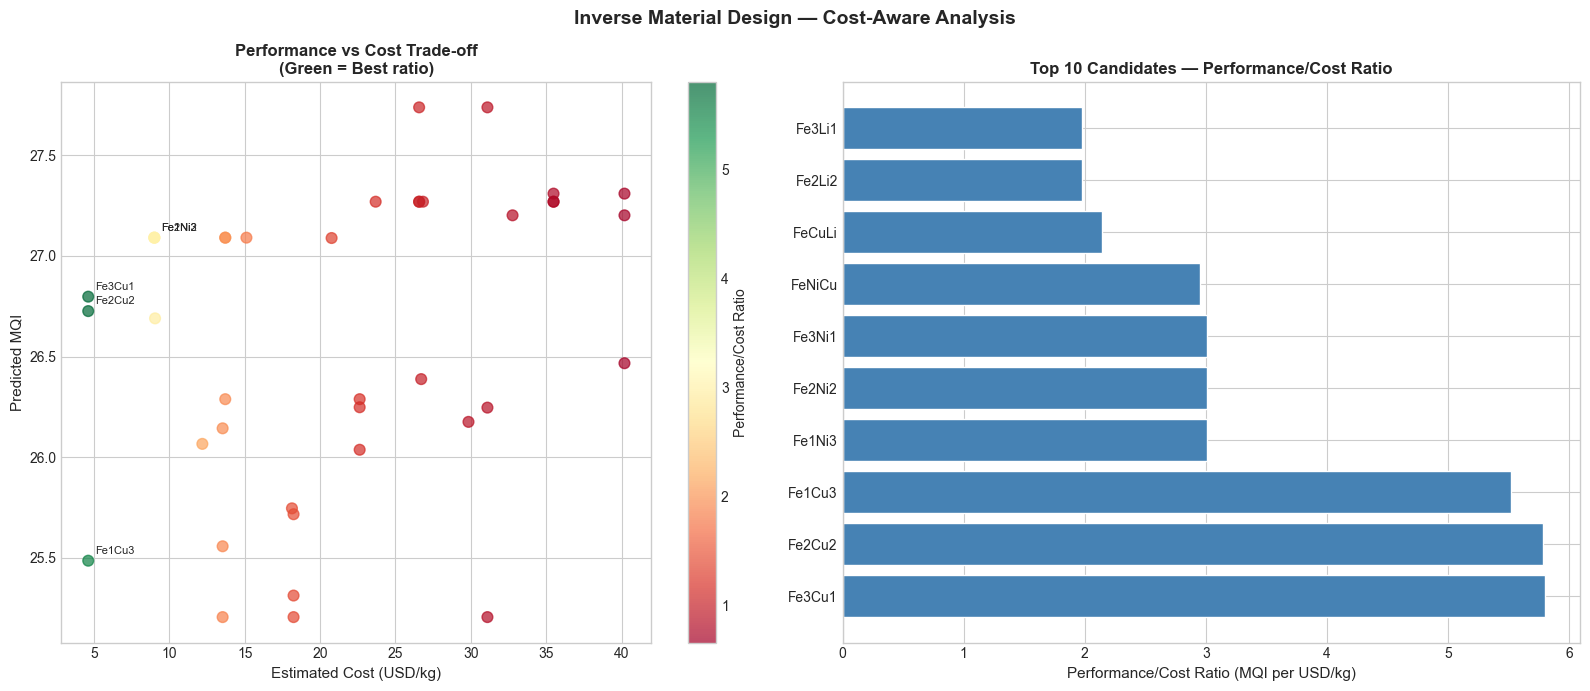

In [12]:
# Visualise performance vs cost trade-off
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Scatter: MQI vs Cost, coloured by performance-cost ratio
scatter = axes[0].scatter(
    results['estimated_cost_usd_kg'],
    results['predicted_MQI'],
    c=results['performance_cost_ratio'],
    cmap='RdYlGn', alpha=0.7, s=60
)
plt.colorbar(scatter, ax=axes[0], label='Performance/Cost Ratio')

# Label top 5 by ratio
top5 = results.nlargest(5, 'performance_cost_ratio')
for _, row in top5.iterrows():
    axes[0].annotate(row['name'],
                     (row['estimated_cost_usd_kg'], row['predicted_MQI']),
                     fontsize=8, ha='left',
                     xytext=(5, 5), textcoords='offset points')

axes[0].set_xlabel('Estimated Cost (USD/kg)', fontsize=11)
axes[0].set_ylabel('Predicted MQI', fontsize=11)
axes[0].set_title('Performance vs Cost Trade-off\n(Green = Best ratio)', fontsize=12, fontweight='bold')

# Bar chart: Top 10 by performance-cost ratio
top10 = results.nlargest(10, 'performance_cost_ratio')
bars = axes[1].barh(top10['name'], top10['performance_cost_ratio'],
                    color='steelblue', edgecolor='white')
axes[1].set_xlabel('Performance/Cost Ratio (MQI per USD/kg)', fontsize=11)
axes[1].set_title('Top 10 Candidates — Performance/Cost Ratio', fontsize=12, fontweight='bold')

plt.suptitle('Inverse Material Design — Cost-Aware Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bonus_performance_cost.png', dpi=150, bbox_inches='tight')
plt.show()

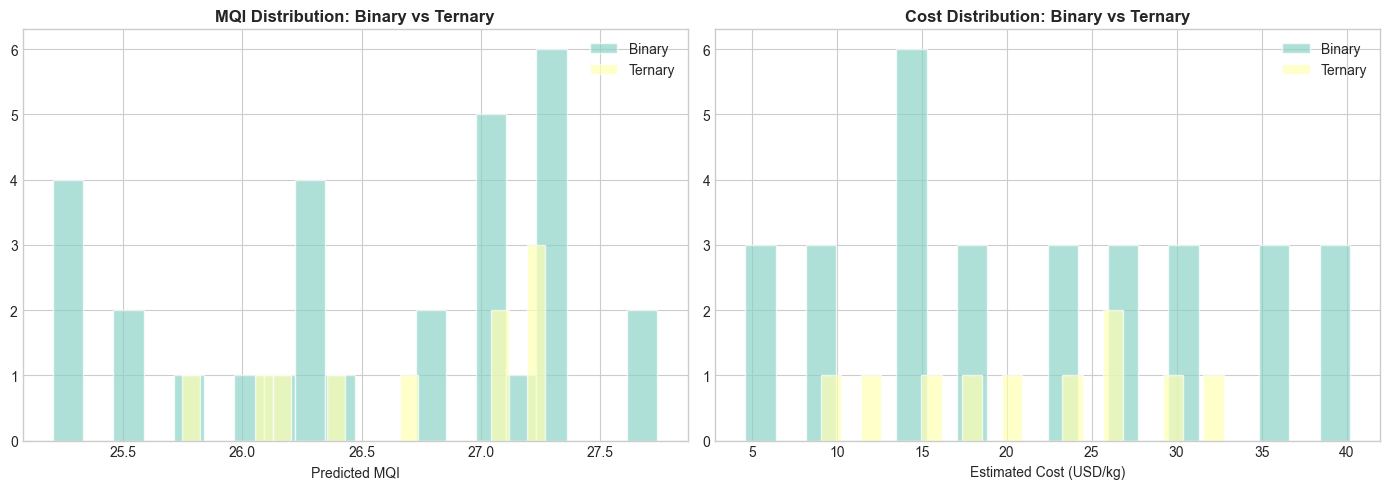

Binary avg MQI: 26.56
Ternary avg MQI: 26.7
Binary avg cost: 21.51
Ternary avg cost: 21.51


In [13]:
# Binary vs Ternary comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (label, group) in enumerate(results.groupby('n_elements')):
    comp_type = 'Binary' if label == 2 else 'Ternary'
    axes[0].hist(group['predicted_MQI'], bins=20, alpha=0.7,
                 label=comp_type, edgecolor='white')
    axes[1].hist(group['estimated_cost_usd_kg'], bins=20, alpha=0.7,
                 label=comp_type, edgecolor='white')

axes[0].set_title('MQI Distribution: Binary vs Ternary', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted MQI')
axes[0].legend()

axes[1].set_title('Cost Distribution: Binary vs Ternary', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Estimated Cost (USD/kg)')
axes[1].legend()

plt.tight_layout()
plt.savefig('bonus_binary_vs_ternary.png', dpi=150, bbox_inches='tight')
plt.show()

print('Binary avg MQI:',   results[results['n_elements']==2]['predicted_MQI'].mean().round(2))
print('Ternary avg MQI:',  results[results['n_elements']==3]['predicted_MQI'].mean().round(2))
print('Binary avg cost:',  results[results['n_elements']==2]['estimated_cost_usd_kg'].mean().round(2))
print('Ternary avg cost:', results[results['n_elements']==3]['estimated_cost_usd_kg'].mean().round(2))

---
## Step 9 — Final Recommendation

In [14]:
best_overall = results.loc[results['performance_cost_ratio'].idxmax()]
best_performance = results.loc[results['predicted_MQI'].idxmax()]
best_economy = results.loc[results['estimated_cost_usd_kg'].idxmin()]

print('=' * 60)
print('BONUS TASK — FINAL RECOMMENDATIONS')
print('=' * 60)
print()
print(' BEST OVERALL (Performance/Cost Trade-off):')
print(f'   Composition:   {best_overall["name"]}')
print(f'   Predicted MQI: {best_overall["predicted_MQI"]:.2f}')
print(f'   Est. Cost:     ${best_overall["estimated_cost_usd_kg"]:.2f}/kg')
print(f'   P/C Ratio:     {best_overall["performance_cost_ratio"]:.3f}')
print()
print(' HIGHEST PERFORMANCE:')
print(f'   Composition:   {best_performance["name"]}')
print(f'   Predicted MQI: {best_performance["predicted_MQI"]:.2f}')
print(f'   Est. Cost:     ${best_performance["estimated_cost_usd_kg"]:.2f}/kg')
print()
print(' MOST ECONOMICAL:')
print(f'   Composition:   {best_economy["name"]}')
print(f'   Predicted MQI: {best_economy["predicted_MQI"]:.2f}')
print(f'   Est. Cost:     ${best_economy["estimated_cost_usd_kg"]:.2f}/kg')
print()
print('METHODOLOGY SUMMARY:')
print('  1. Trained GradientBoosting on DS1 to predict MQI from material properties')
print('  2. Generated binary and ternary candidate alloys from Fe, Ni, Cu, Li, Co')
print('  3. Estimated candidate properties by blending element profiles from DS1')
print('  4. Predicted MQI for each candidate using trained model')
print('  5. Estimated cost using latest element prices from DS5')
print('  6. Ranked by performance-cost ratio to find optimal trade-off')

BONUS TASK — FINAL RECOMMENDATIONS

 BEST OVERALL (Performance/Cost Trade-off):
   Composition:   Fe3Cu1
   Predicted MQI: 26.80
   Est. Cost:     $4.62/kg
   P/C Ratio:     5.800

 HIGHEST PERFORMANCE:
   Composition:   Fe1Co3
   Predicted MQI: 27.74
   Est. Cost:     $26.57/kg

 MOST ECONOMICAL:
   Composition:   Fe1Cu3
   Predicted MQI: 25.49
   Est. Cost:     $4.62/kg

METHODOLOGY SUMMARY:
  1. Trained GradientBoosting on DS1 to predict MQI from material properties
  2. Generated binary and ternary candidate alloys from Fe, Ni, Cu, Li, Co
  3. Estimated candidate properties by blending element profiles from DS1
  4. Predicted MQI for each candidate using trained model
  5. Estimated cost using latest element prices from DS5
  6. Ranked by performance-cost ratio to find optimal trade-off
